In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parents[0]))  # Graph-SSL
print(sys.path[-1])
from wl_gcl.src.utils.wl_core import WLHierarchyEngine
import torch
import networkx as nx



/mnt/D/graph_ssl/Graph-SSL


In [2]:
G = nx.karate_club_graph()

nodes = list(G.nodes())
edges = list(G.edges())

engine = WLHierarchyEngine(nodes, edges)
engine.build_wl_tree(max_iterations=6)


Building WL Tree (Convergence Mode: False)...
-> Stable convergence reached at iteration 2.


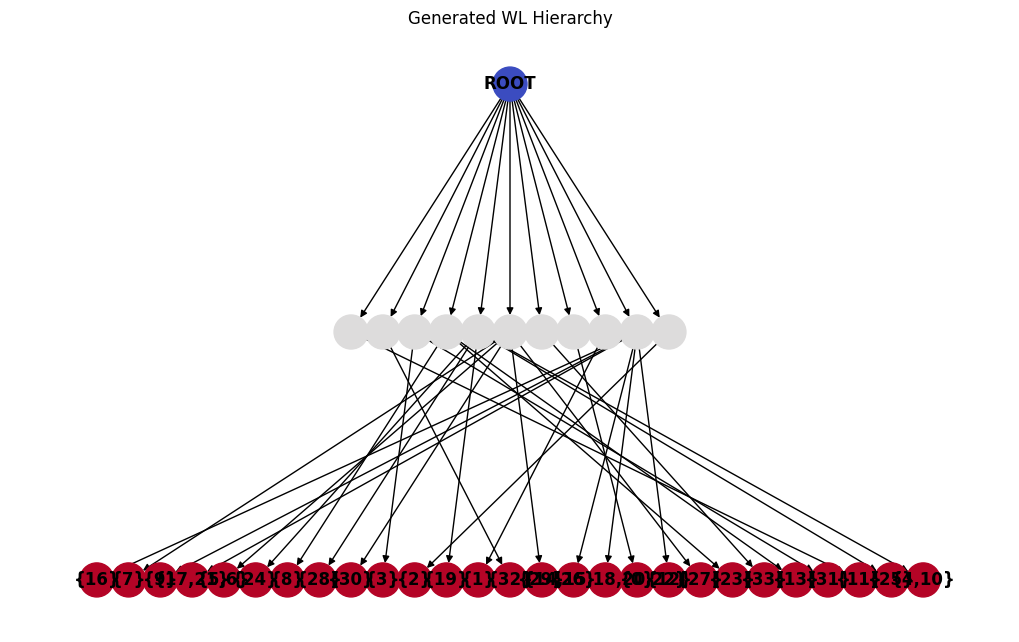

In [3]:
engine.visualize_hierarchy()


In [4]:
for node in [0, 5, 32]:
    print(f"\nWL path for node {node}")
    print(engine.get_wl_path(node))



WL path for node 0
[(0, 'root'), (1, 'It1_67b74dad'), (2, 'It2_f935a444')]

WL path for node 5
[(0, 'root'), (1, 'It1_9f348ecd'), (2, 'It2_12b0a1af')]

WL path for node 32
[(0, 'root'), (1, 'It1_f88501b4'), (2, 'It2_4548a7f0')]


In [5]:
# clusters at different levels for a specific node
node = 8
levels = sorted(engine.node_path[node].keys())

for t in levels:
    cluster = engine.get_cluster_at_level(node, t)
    print(f"Level {t}: size={len(cluster)} → {cluster}")


Level 0: size=34 → [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Level 1: size=3 → [8, 13, 23]
Level 2: size=1 → [8]


In [6]:
#extracting wl-hard negatives at every level t
node = 5
levels = sorted(engine.node_path[node].keys())

for t in levels[1:]:
    hard_neg = engine.get_hard_negatives(node, t)
    print(f"Hard negatives at level {t}: {hard_neg}")


Hard negatives at level 1: [0, 1, 2, 3, 4, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 31, 32, 33]
Hard negatives at level 2: [27, 29, 30, 7]


In [7]:
# structural similarity
pairs = [(5, 7), (5, 0), (5, 33)]
for u, v in pairs:
    sim = engine.get_structural_similarity(u, v)
    print(f"Similarity({u},{v}) = {sim:.3f}")


Similarity(5,7) = 0.500
Similarity(5,0) = 0.000
Similarity(5,33) = 0.000


In [8]:
#wl-based distance and similarity
pairs = [(5,7), (5,0), (5,33)]

for u, v in pairs:
    d = engine.get_wl_distance(u, v)
    s = engine.get_wl_similarity(u, v)
    print(f"{u}-{v} → distance={d}, similarity={s:.3f}")


5-7 → distance=1, similarity=0.500
5-0 → distance=2, similarity=0.000
5-33 → distance=2, similarity=0.000


In [9]:
N = len(nodes)
z = torch.randn(N, 16)

level = 1
centroids = engine.compute_centroids(z, level)

print(f"Number of clusters at level {level}: {len(centroids)}")


Number of clusters at level 1: 11


In [10]:
node = 5
levels = sorted(engine.node_path[node].keys())

if len(levels) >= 3:
    t1, t2 = levels[1], levels[2]

    centroids_t1 = engine.compute_centroids(z, t1)
    centroids_t2 = engine.compute_centroids(z, t2)

    cid1 = engine.get_cluster_id(node, t1)
    cid2 = engine.get_cluster_id(node, t2)

    print("Centroid distance:",
          (centroids_t1[cid1] - centroids_t2[cid2]).norm())


Centroid distance: tensor(2.2023)


In [11]:
node = 5
t = levels[-1]  # deepest WL level

positives = engine.get_cluster_at_level(node, t)
hard_neg = engine.get_hard_negatives(node, t)

print("Positives:", positives)
print("Hard negatives:", hard_neg)


Positives: [5, 6]
Hard negatives: [27, 29, 30, 7]
